In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First, I'll unzip the `test.zip` and `train.zip` files from your Google Drive.

In [7]:
import os
from PIL import Image

def clean_corrupted_images(directory):
    print(f"Scanning {directory} for corrupted or empty images...")
    deleted_count = 0

    for root, dirs, files in os.walk(directory):
        for file in files:
            # Skip hidden files like .DS_Store
            if file.startswith('.'):
                continue

            file_path = os.path.join(root, file)

            # Check 1: Is the file completely empty?
            if os.path.getsize(file_path) == 0:
                print(f"Removing empty file: {file_path}")
                os.remove(file_path)
                deleted_count += 1
                continue

            # Check 2: Can an image library actually open and decode it?
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Verifies the image is not broken
            except (IOError, SyntaxError) as e:
                print(f"Removing corrupted image: {file_path}")
                os.remove(file_path)
                deleted_count += 1

    print(f"Scan complete. Cleaned up {deleted_count} bad files.\n")

# Run the cleanup on both directories
clean_corrupted_images('/content/drive/MyDrive/fed/train')
clean_corrupted_images('/content/drive/MyDrive/fed/test')

Scanning /content/drive/MyDrive/fed/train for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Scanning /content/drive/MyDrive/fed/test for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.



Scanning /content/drive/MyDrive/fed/train for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Scanning /content/drive/MyDrive/fed/test for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Found 28708 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

--- Training Custom CNN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - accuracy: 0.3388 - loss: 1.6678 - val_accuracy: 0.4273 - val_loss: 1.4900
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4629 - loss: 1.4100 - val_accuracy: 0.4837 - val_loss: 1.3599
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5089 - loss: 1.2963 - val_accuracy: 0.5070 - val_loss: 1.2893
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5429 - loss: 1.2170 - val_accuracy: 0.5201 - val_loss: 1.2505
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5698 - loss: 1.1510 - val_accuracy: 0.5313 - val_loss: 1.2275
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5313 - loss: 1.2275
Test Loss: 1.2275
Test Accuracy: 0.5313


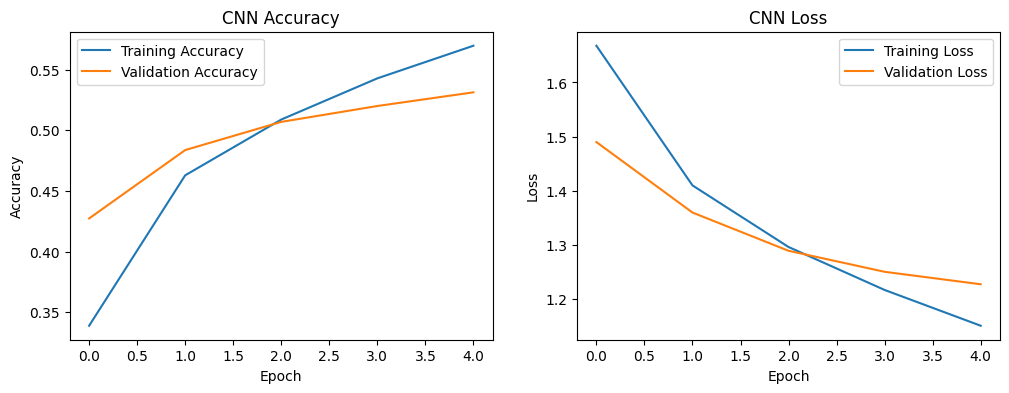

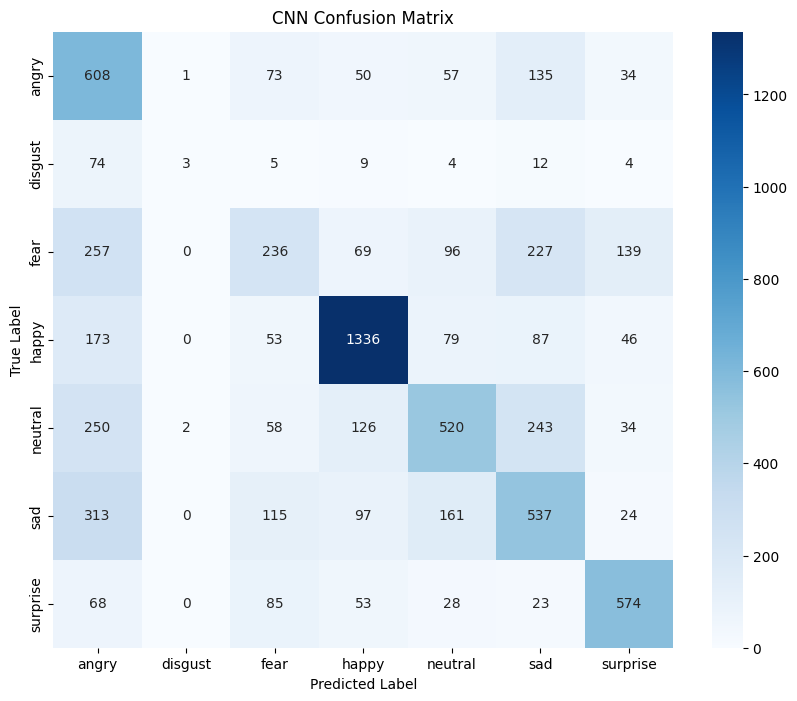


--- Training ResNet50 Transfer Learning Model ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.2398 - loss: 1.8280 - val_accuracy: 0.2463 - val_loss: 1.7929
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2556 - loss: 1.7970 - val_accuracy: 0.2534 - val_loss: 1.7795
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.2576 - loss: 1.7853 - val_accuracy: 0.2640 - val_loss: 1.7665
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.2670 - loss: 1.7714 - val_accuracy: 0.2768 - val_loss: 1.7533
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2709 - loss: 1.7651 - val_accuracy: 0.2850 - val_loss: 1.7399
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2758 - loss: 1.7558 - val_accuracy: 0.2843 - val_loss: 1.7316
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.2775 - loss: 1.7512 - val_accuracy: 0.2866 - val_loss: 1

In [3]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# ==========================================
# 1. CLEANUP CORRUPTED FILES FIRST
# ==========================================
def clean_corrupted_images(directory):
    print(f"Scanning {directory} for corrupted or empty images...")
    deleted_count = 0

    if not os.path.exists(directory):
        print(f"Directory {directory} does not exist. Skipping.")
        return

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.startswith('.'):
                continue

            file_path = os.path.join(root, file)

            # Check for 0 KB files
            if os.path.getsize(file_path) == 0:
                print(f"Removing empty file: {file_path}")
                os.remove(file_path)
                deleted_count += 1
                continue

            # Check if image can be decoded
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                print(f"Removing corrupted image: {file_path}")
                os.remove(file_path)
                deleted_count += 1

    print(f"Scan complete. Cleaned up {deleted_count} bad files.\n")

# Target directories
train_dir = '/content/drive/MyDrive/fed/train'
test_dir = '/content/drive/MyDrive/fed/test'

# Run cleanup before loading
clean_corrupted_images(train_dir)
clean_corrupted_images(test_dir)


# ==========================================
# 2. PARAMETERS & DATA LOADING
# ==========================================
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64      # Explicitly set to 128
LEARNING_RATE =0.0005  # Increased learning rate

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load the testing dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Normalization function
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply normalization and performance optimization
train_ds = train_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)


# ==========================================
# 3. CUSTOM CNN MODEL
# ==========================================
print("\n--- Training Custom CNN Model ---")
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)


# ==========================================
# 4. EVALUATION & VISUALIZATION (CNN)
# ==========================================
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plotting metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

# Confusion Matrix
y_true = []
y_pred = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.show()


# ==========================================
# 5. RESNET50 TRANSFER LEARNING
# ==========================================
print("\n--- Training ResNet50 Transfer Learning Model ---")

base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
base_model.trainable = False

resnet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

RESNET_EPOCHS = 15
history_resnet = resnet_model.fit(
    train_ds,       # Fixed: correctly passing data object instead of string path
    validation_data=test_ds,
    epochs=RESNET_EPOCHS
)
print("ResNet50 Training Completed successfully!")

Scanning /content/drive/MyDrive/fed/train for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Scanning /content/drive/MyDrive/fed/test for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Found 28708 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

--- Training Custom CNN Model ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


449/449 ━━━━━━━━━━━━━━━━━━━━ 158s 341ms/step - accuracy: 0.3450 - loss: 1.6593 - val_accuracy: 0.4331 - val_loss: 1.4790
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4677 - loss: 1.4009 - val_accuracy: 0.4861 - val_loss: 1.3498
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5196 - loss: 1.2758 - val_accuracy: 0.5150 - val_loss: 1.2731
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5525 - loss: 1.1885 - val_accuracy: 0.5309 - val_loss: 1.2285
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5804 - loss: 1.1193 - val_accuracy: 0.5433 - val_loss: 1.2168
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5433 - loss: 1.2168
Test Loss: 1.2168
Test Accuracy: 0.5433


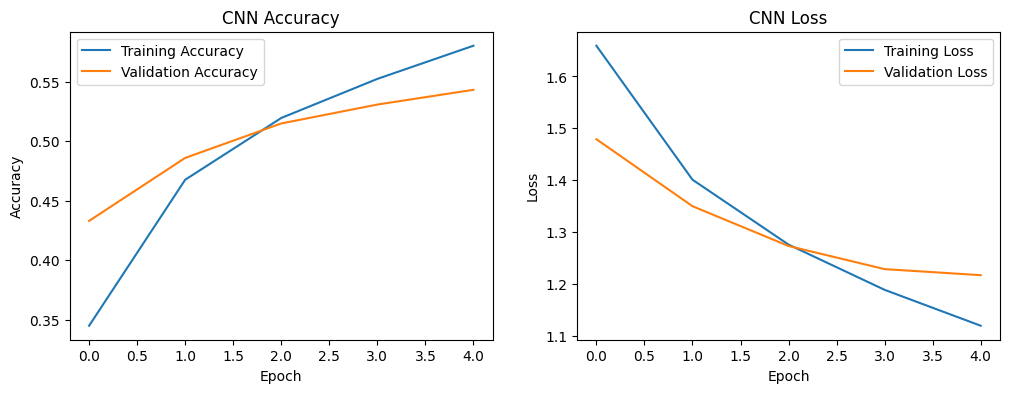

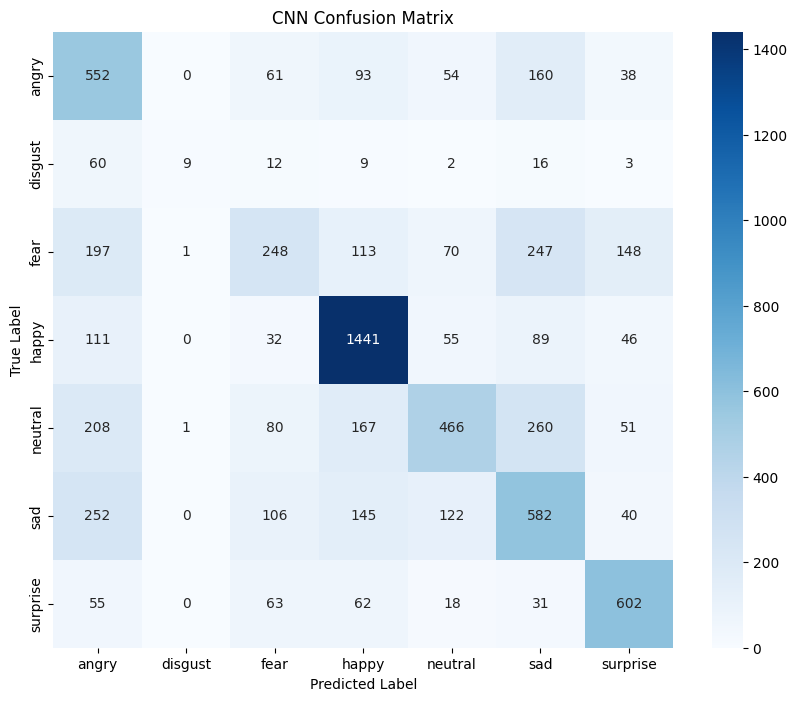


--- Training ResNet50 Transfer Learning Model ---
Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.2342 - loss: 1.8327 - val_accuracy: 0.2470 - val_loss: 1.8038
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2496 - loss: 1.8135 - val_accuracy: 0.2471 - val_loss: 1.8010
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.2510 - loss: 1.8081 - val_accuracy: 0.2508 - val_loss: 1.7899
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.2531 - loss: 1.8046 - val_accuracy: 0.2526 - val_loss: 1.7887
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.2542 - loss: 1.8000 - val_accuracy: 0.2516 - val_loss: 1.7832
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.2547 - loss: 1.7986 - val_accuracy: 0.2615 - val_loss: 1.7842
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.2555 - loss: 1.7978 - val_accuracy: 0.2602 - val_loss: 1.7795
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# ==========================================
# 1. CLEANUP CORRUPTED FILES FIRST
# ==========================================
def clean_corrupted_images(directory):
    print(f"Scanning {directory} for corrupted or empty images...")
    deleted_count = 0

    if not os.path.exists(directory):
        print(f"Directory {directory} does not exist. Skipping.")
        return

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.startswith('.'):
                continue

            file_path = os.path.join(root, file)

            # Check for 0 KB files
            if os.path.getsize(file_path) == 0:
                print(f"Removing empty file: {file_path}")
                os.remove(file_path)
                deleted_count += 1
                continue

            # Check if image can be decoded
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                print(f"Removing corrupted image: {file_path}")
                os.remove(file_path)
                deleted_count += 1

    print(f"Scan complete. Cleaned up {deleted_count} bad files.\n")

# Target directories
train_dir = '/content/drive/MyDrive/fed/train'
test_dir = '/content/drive/MyDrive/fed/test'

# Run cleanup before loading
clean_corrupted_images(train_dir)
clean_corrupted_images(test_dir)


# ==========================================
# 2. PARAMETERS & DATA LOADING
# ==========================================
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
LEARNING_RATE = 0.0005

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load the testing dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Normalization function
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply normalization and performance optimization
train_ds = train_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)


# ==========================================
# 3. CUSTOM CNN MODEL
# ==========================================
print("\n--- Training Custom CNN Model ---")
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)


# ==========================================
# 4. EVALUATION & VISUALIZATION (CNN)
# ==========================================
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plotting metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

# Confusion Matrix
y_true = []
y_pred = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.show()


# ==========================================
# 5. RESNET50 TRANSFER LEARNING WITH DATA AUGMENTATION
# ==========================================
print("\n--- Training ResNet50 Transfer Learning Model ---")

base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
# Keeping base_model.trainable = False initially is recommended when using pre-trained weights
base_model.trainable = False

# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

# FIXED: Reassembled the sequence completely and closed all brackets properly
resnet_model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

RESNET_EPOCHS = 15
history_resnet = resnet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=RESNET_EPOCHS
)
print("ResNet50 Training Completed successfully!")

Scanning /content/drive/MyDrive/fed/train for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Scanning /content/drive/MyDrive/fed/test for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Found 28708 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

--- Training Custom CNN Model ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


449/449 ━━━━━━━━━━━━━━━━━━━━ 150s 319ms/step - accuracy: 0.3405 - loss: 1.6730 - val_accuracy: 0.4104 - val_loss: 1.5218
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4558 - loss: 1.4285 - val_accuracy: 0.4727 - val_loss: 1.3773
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5051 - loss: 1.3064 - val_accuracy: 0.4960 - val_loss: 1.3151
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5404 - loss: 1.2240 - val_accuracy: 0.5125 - val_loss: 1.2708
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5669 - loss: 1.1548 - val_accuracy: 0.5223 - val_loss: 1.2506
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5223 - loss: 1.2506
Test Loss: 1.2506
Test Accuracy: 0.5223


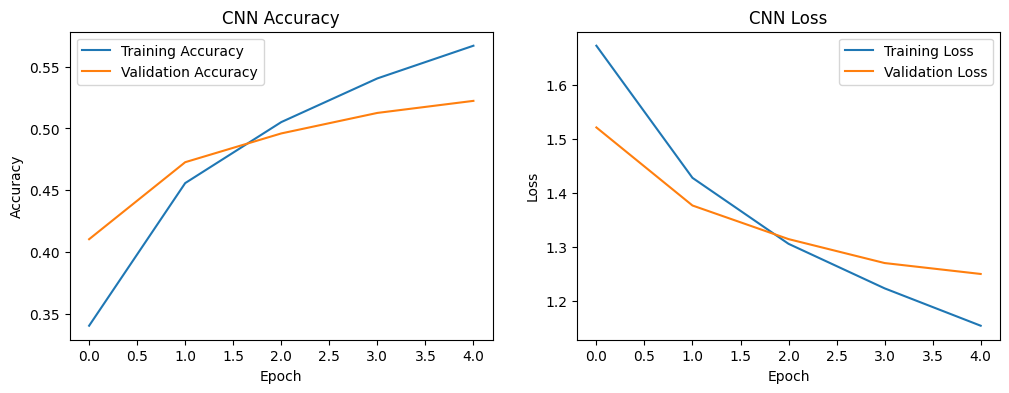

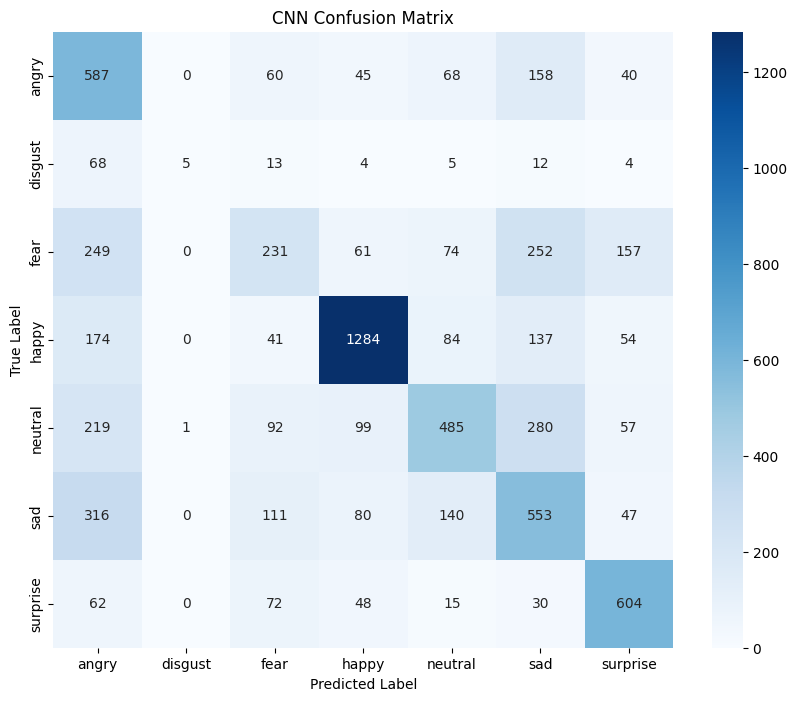


--- Training ResNet50 Transfer Learning Model ---
Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.2352 - loss: 1.8357 - val_accuracy: 0.2487 - val_loss: 1.7978
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2474 - loss: 1.8133 - val_accuracy: 0.2498 - val_loss: 1.7969
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.2505 - loss: 1.8066 - val_accuracy: 0.2551 - val_loss: 1.7893
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2529 - loss: 1.8025 - val_accuracy: 0.2534 - val_loss: 1.7881
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2532 - loss: 1.8009 - val_accuracy: 0.2584 - val_loss: 1.7837
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2535 - loss: 1.7996 - val_accuracy: 0.2685 - val_loss: 1.7795
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2563 - loss: 1.7957 - val_accuracy: 0.2700 - val_loss: 1.7748
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━

In [5]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# ==========================================
# 1. CLEANUP CORRUPTED FILES FIRST
# ==========================================
def clean_corrupted_images(directory):
    print(f"Scanning {directory} for corrupted or empty images...")
    deleted_count = 0

    if not os.path.exists(directory):
        print(f"Directory {directory} does not exist. Skipping.")
        return

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.startswith('.'):
                continue

            file_path = os.path.join(root, file)

            # Check for 0 KB files
            if os.path.getsize(file_path) == 0:
                print(f"Removing empty file: {file_path}")
                os.remove(file_path)
                deleted_count += 1
                continue

            # Check if image can be decoded
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                print(f"Removing corrupted image: {file_path}")
                os.remove(file_path)
                deleted_count += 1

    print(f"Scan complete. Cleaned up {deleted_count} bad files.\n")

# Target directories
train_dir = '/content/drive/MyDrive/fed/train'
test_dir = '/content/drive/MyDrive/fed/test'

# Run cleanup before loading
clean_corrupted_images(train_dir)
clean_corrupted_images(test_dir)


# ==========================================
# 2. PARAMETERS & DATA LOADING
# ==========================================
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
LEARNING_RATE = 0.0005

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load the testing dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Normalization function
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply normalization and performance optimization
train_ds = train_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)


# ==========================================
# 3. CUSTOM CNN MODEL
# ==========================================
print("\n--- Training Custom CNN Model ---")
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)


# ==========================================
# 4. EVALUATION & VISUALIZATION (CNN)
# ==========================================
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plotting metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

# Confusion Matrix
y_true = []
y_pred = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.show()


# ==========================================
# 5. RESNET50 TRANSFER LEARNING WITH DATA AUGMENTATION
# ==========================================
print("\n--- Training ResNet50 Transfer Learning Model ---")

base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
# Keeping base_model.trainable = False initially is recommended when using pre-trained weights
base_model.trainable = False

# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

# FIXED: Reassembled the sequence completely and closed all brackets properly
resnet_model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

RESNET_EPOCHS = 30
history_resnet = resnet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=RESNET_EPOCHS
)
print("ResNet50 Training Completed successfully!")

Hybrib model

Combination of CNN and ResNet50

Scanning /content/drive/MyDrive/fed/train for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Scanning /content/drive/MyDrive/fed/test for corrupted or empty images...
Scan complete. Cleaned up 0 bad files.

Found 28708 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

--- Building Hybrid CNN-ResNet50 Model ---


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_2       │ (None, 48, 48, 3) │          0 │ input_layer_11[0… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 48, 48, 3) │          0 │ random_flip_2[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 46, 46,    │        896 │ random_rotation_… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 23, 23,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 21, 21,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 10, 10,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 4, 4, 128) │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2, 2,      │ 23,587,712 │ random_rotation_… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2048)      │          0 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4096)      │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │  1,048,832 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 7)         │      1,799 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,731,591 (94.34 MB)

 Trainable params: 1,143,879 (4.36 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


--- Training Hybrid Model ---
Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 162s 338ms/step - accuracy: 0.2366 - loss: 1.8208 - val_accuracy: 0.2937 - val_loss: 1.7352
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.2755 - loss: 1.7532 - val_accuracy: 0.3320 - val_loss: 1.6722
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.3240 - loss: 1.6854 - val_accuracy: 0.3958 - val_loss: 1.5610
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.3597 - loss: 1.6159 - val_accuracy: 0.3977 - val_loss: 1.5338
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.3846 - loss: 1.5731 - val_accuracy: 0.4510 - val_loss: 1.4318
Epoch 6/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.4022 - loss: 1.5326 - val_accuracy: 0.4611 - val_loss: 1.4031
Epoch 7/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.4150 - loss: 1.5034 - val_accuracy: 0.4756 - val_loss: 1.3758
Epoch 8/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - a

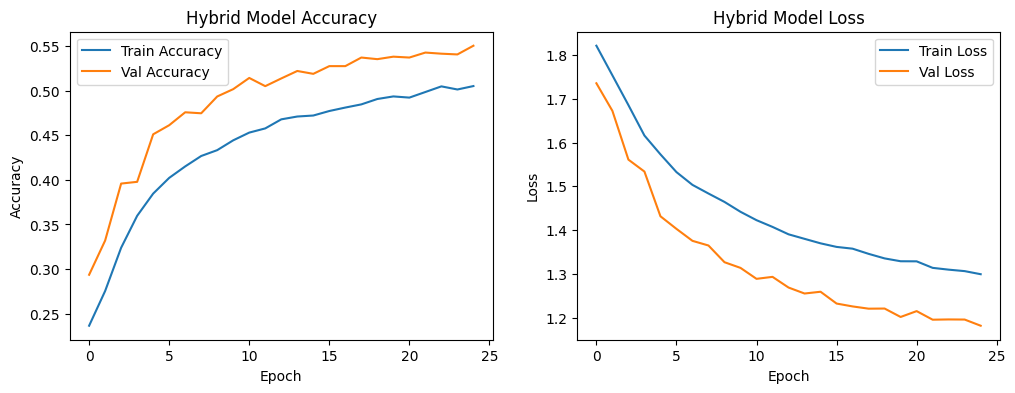

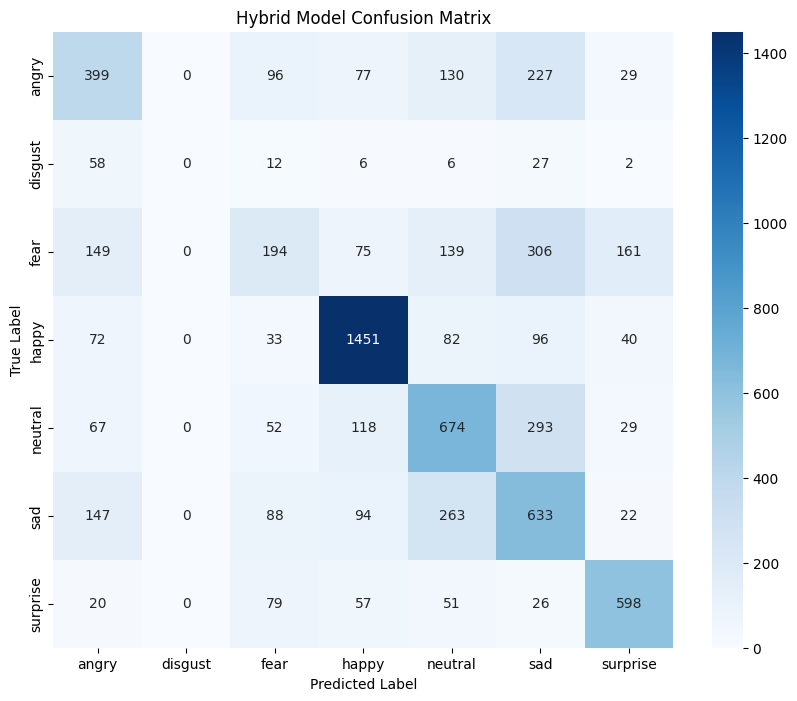

In [8]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# ==========================================
# 1. CLEANUP CORRUPTED FILES
# ==========================================
def clean_corrupted_images(directory):
    print(f"Scanning {directory} for corrupted or empty images...")
    deleted_count = 0

    if not os.path.exists(directory):
        print(f"Directory {directory} does not exist. Skipping.")
        return

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.startswith('.'):
                continue
            file_path = os.path.join(root, file)
            if os.path.getsize(file_path) == 0:
                os.remove(file_path)
                deleted_count += 1
                continue
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                os.remove(file_path)
                deleted_count += 1
    print(f"Scan complete. Cleaned up {deleted_count} bad files.\n")

train_dir = '/content/drive/MyDrive/fed/train'
test_dir = '/content/drive/MyDrive/fed/test'

clean_corrupted_images(train_dir)
clean_corrupted_images(test_dir)

# ==========================================
# 2. PARAMETERS & DATA LOADING
# ==========================================
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
LEARNING_RATE = 0.0005

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
    batch_size=BATCH_SIZE, shuffle=True, seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
    batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names

def normalize(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# ==========================================
# 3. HYBRID MODEL ARCHITECTURE (FUNCTIONAL API)
# ==========================================
print("\n--- Building Hybrid CNN-ResNet50 Model ---")

# Shared Input
input_layer = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Shared Data Augmentation Layer (applies during training only)
augmented = layers.RandomFlip("horizontal")(input_layer)
augmented = layers.RandomRotation(0.1)(augmented)

# --- Branch 1: Your Custom CNN ---
cnn_branch = layers.Conv2D(32, (3, 3), activation='relu')(augmented)
cnn_branch = layers.MaxPooling2D((2, 2))(cnn_branch)
cnn_branch = layers.Conv2D(64, (3, 3), activation='relu')(cnn_branch)
cnn_branch = layers.MaxPooling2D((2, 2))(cnn_branch)
cnn_branch = layers.Conv2D(128, (3, 3), activation='relu')(cnn_branch)
cnn_branch = layers.MaxPooling2D((2, 2))(cnn_branch)
cnn_branch = layers.Flatten()(cnn_branch)

# --- Branch 2: ResNet50 Transfer Learning ---
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False  # Freeze pretrained weights

resnet_branch = base_model(augmented)
resnet_branch = layers.GlobalAveragePooling2D()(resnet_branch)

# --- Merge Branches ---
merged = layers.concatenate([cnn_branch, resnet_branch])

# --- Dense Classification Top ---
x = layers.Dense(256, activation='relu')(merged)
x = layers.Dropout(0.5)(x)
output_layer = layers.Dense(len(class_names), activation='softmax')(x)

# Create the Hybrid Model
hybrid_model = models.Model(inputs=input_layer, outputs=output_layer)

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()

# ==========================================
# 4. TRAINING
# ==========================================
HYBRID_EPOCHS = 25
print("\n--- Training Hybrid Model ---")
history = hybrid_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=HYBRID_EPOCHS
)

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================
loss, accuracy = hybrid_model.evaluate(test_ds)
print(f"\nHybrid Test Loss: {loss:.4f}")
print(f"Hybrid Test Accuracy: {accuracy:.4f}")

# Metrics Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Hybrid Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Hybrid Model Loss')
plt.legend()
plt.show()

# Confusion Matrix
y_true = []
y_pred = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = hybrid_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Hybrid Model Confusion Matrix')
plt.show()